In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

# Import dataset

In [2]:
df=pd.read_csv("adult.csv")

# Exploratory Data Analysis

Display and Analyze the dataset

In [3]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [5]:
df.shape

(32561, 15)

In [6]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

# Checking the presence of Missing Values

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Info of the dataset shows that there are no missing values. But the head() shows that the dataset contains values coded as `?`. So, I will encode `?` as NaN values.

In [8]:
df[df == '?'] = np.nan

In [9]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

Now, it shows that the variables - workclass, occupation and native.country contain missing values. All of these variables are categorical data type. So, I will impute the missing values with the most frequent value- the mode.

# Impute missing values with mode

In [10]:
for col in ['workclass', 'occupation', 'native.country']:
    df[col].fillna(df[col].mode()[0], inplace=True)

In [11]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

Now we can see that there are no missing values in the dataset.

# Split dataset into independent (X) and dependent (Y) variable

In [12]:
X = df.drop(['income'], axis=1)

y = df['income']

In [13]:
y.reset_index(drop=True, inplace=True)  # As needed
y2 = pd.DataFrame(y)

y2.head()

,income
0,<=50K
1,<=50K
2,<=50K
3,<=50K
4,<=50K


In [14]:
from sklearn import preprocessing
le = preprocessing.LabelEncoder()
le.fit(y2['income'])
y3 = le.transform(y2['income'])

/home/karim/.local/lib/python3.8/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.1
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# Split data into training and testing dataset

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y3, test_size = 0.3, random_state = 0)

# Feature Engineering

Encode categorical variables

In [16]:
from sklearn import preprocessing

categorical = ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']
for feature in categorical:
        label = preprocessing.LabelEncoder()
        X_train[feature] = label.fit_transform(X_train[feature])
        X_test[feature] = label.transform(X_test[feature])

# Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = pd.DataFrame(scaler.fit_transform(X_train), columns = X.columns)

X_test = pd.DataFrame(scaler.transform(X_test), columns = X.columns)
X_train.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,0.101484,2.600478,-1.494279,-0.332263,1.133894,-0.402341,-0.782234,2.214196,0.39298,-1.430470,-0.145189,-0.217407,-1.662414,0.262317
1,0.028248,-1.884720,0.438778,0.184396,-0.423425,-0.402341,-0.026696,-0.899410,0.39298,0.699071,-0.145189,-0.217407,-0.200753,0.262317
2,0.247956,-0.090641,0.045292,1.217715,-0.034095,0.926666,-0.782234,-0.276689,0.39298,-1.430470,-0.145189,-0.217407,-0.038346,0.262317
3,-0.850587,-1.884720,0.793152,0.184396,-0.423425,0.926666,-0.530388,0.968753,0.39298,0.699071,-0.145189,-0.217407,-0.038346,0.262317
4,-0.044989,-2.781760,-0.853275,0.442726,1.523223,-0.402341,-0.782234,-0.899410,0.39298,0.699071,-0.145189,-0.217407,-0.038346,0.262317


In [18]:
# Import the classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, AdaBoostClassifier, GradientBoostingClassifier

from sklearn.metrics import roc_curve, roc_auc_score

In [32]:
# Instantiate the classfiers and make a list
classifiers = [ExtraTreesClassifier(), 
               AdaBoostClassifier(), 
               GradientBoostingClassifier(), 
               RandomForestClassifier()]

# Define a result table as a DataFrame
result_table = pd.DataFrame(columns=['classifiers', 'fpr','tpr','auc'])
# names = ['LR', 'NB', 'KNN', 'RF']
#names = ['Node2vec+XGBoost', 'Attri2Vec+XGBoost', 'GraphSAGE+XGBoost', 'DGT+XGBoost'] 
names = ['Node2vec+XGBoost', 'GraphSAGE+XGBoost', 'DGT+XGBoost', 'Attri2Vec+XGBoost'] 

# Train the models and record the results
for cls in classifiers:
    model = cls.fit(X_train, y_train)
    yproba = model.predict_proba(X_test)[::,1]
    
    fpr, tpr, _ = roc_curve(y_test,  yproba)
    auc = roc_auc_score(y_test, yproba)
    print(cls.__class__.__name__)    
   
    result_table = result_table.append({'classifiers':cls.__class__.__name__,
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}, ignore_index=True)

# Set name of the classifiers as index labels
result_table.set_index('classifiers', inplace=True)

ExtraTreesClassifier
AdaBoostClassifier
GradientBoostingClassifier
RandomForestClassifier


In [20]:
# Instantiate the classfiers and make a list
# classifiers = [LogisticRegression(random_state=1234), 
#                GaussianNB(), 
#                RandomForestClassifier(random_state=1234)]

classifiers = [LogisticRegression(max_iter=1000),
               GaussianNB(), 
               GradientBoostingClassifier(),
               RandomForestClassifier()]

# Define a result table as a DataFrame
result_table = pd.DataFrame(columns=['classifiers', 'fpr','tpr','auc'])
# names = ['LR', 'NB', 'KNN', 'RF']
names = ['Node2vec+XGBoost', 'GraphSAGE+XGBoost', 'Attri2Vec+XGBoost', 'DGT+XGBoost'] 
#names = ['FastGCN', 'Skip-GCN', 'EvolveGCN'] 


# Train the models and record the results
for cls in classifiers:
    model = cls.fit(X_train, y_train)
    yproba = model.predict_proba(X_test)[::,1]
    
    fpr, tpr, _ = roc_curve(y_test,  yproba)
    auc = roc_auc_score(y_test, yproba)
    print(cls.__class__.__name__)    
   
    result_table = result_table.append({'classifiers':cls.__class__.__name__,
                                        'fpr':fpr, 
                                        'tpr':tpr, 
                                        'auc':auc}, ignore_index=True)

# Set name of the classifiers as index labels
result_table.set_index('classifiers', inplace=True)

LogisticRegression
GaussianNB
GradientBoostingClassifier
RandomForestClassifier


In [33]:
import pandas as pd
result_table['classifiers'] = pd.Series(names)
result_table2 = result_table.assign(classifiers=names)
result_table2.reset_index(drop=True, inplace=True)
result_table2.set_index('classifiers', inplace=True)

In [34]:
result_table2.head()

,fpr,tpr,auc
classifiers,,,
Node2vec+XGBoost,"[0.0, 0.0005398110661268556, 0.000944669365721...","[0.0, 0.027977956761339552, 0.0538363713437897...",0.885281
GraphSAGE+XGBoost,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.000423908435777872, 0.0016956337431114...",0.912127
DGT+XGBoost,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 0.000423908435777872, 0.0097498940228910...",0.917928
Attri2Vec+XGBoost,"[0.0, 0.0, 0.0, 0.0002699055330634278, 0.00080...","[0.0, 0.05086901229334464, 0.0907164052564646,...",0.901700


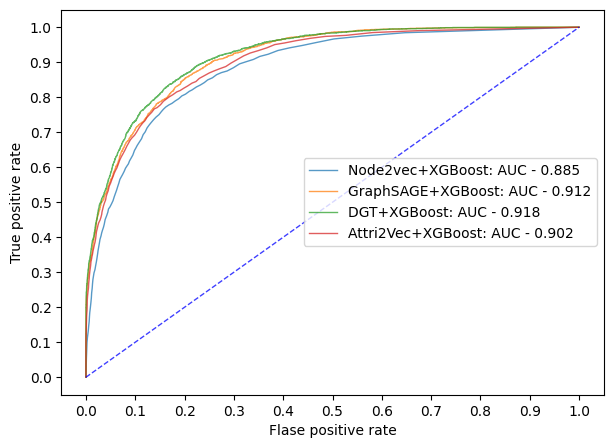

In [35]:
%matplotlib inline
import matplotlib.pyplot as plt
# plt.style.use('seaborn')
# from matplotlib import rcParams
# rcParams['font.size'] = 6

plt.rcdefaults()
plt.rcParams['font.size'] = 10

fig = plt.figure(figsize=(7,5))

for i in result_table2.index:
    plt.plot(result_table2.loc[i]['fpr'], 
             result_table2.loc[i]['tpr'], 
             label="{}: AUC - {:.3f}".format(i, result_table2.loc[i]['auc']), alpha=0.75, linewidth=1)
    
plt.plot([0,1], [0,1], color='blue', linestyle='--', alpha=0.75, linewidth=1)

plt.xticks(np.arange(0.0, 1.1, step=0.1))
plt.xlabel("Flase positive rate")

plt.yticks(np.arange(0.0, 1.1, step=0.1))
plt.ylabel("True positive rate")

# plt.title('AUC-ROC')
plt.legend(prop={'size':10}, loc="center right")
plt.grid(False)

plt.savefig('auc_roc_pipeline_elliptic.png', dpi=800, transparent=True)
plt.show()